## Data cleaning and Feature Engineering

In [ ]:
import pandas as pd
import numpy as np
import re
from pathlib import Path

EMB_PATH = Path("../data/processed/08.FRAIL_with_tsvd_10dim.csv")
LLM_PATH = Path("../data/processed/09.llm.csv")
DROP_PERCENTILES = False  # True se quiseres remover colunas Percentil*

print("--- A CARREGAR DADOS ---")
emb = pd.read_csv(EMB_PATH)
llm = pd.read_csv(LLM_PATH)
print(f"Embeddings: {emb.shape}")
print(f"LLM Data:   {llm.shape}")

# Garantir chaves numéricas
for k in ["ID_Aluno", "Momento"]:
    emb[k] = pd.to_numeric(emb[k], errors="coerce").astype("Int64")
    llm[k] = pd.to_numeric(llm[k], errors="coerce").astype("Int64")

# Deduplicar antes do merge
emb = emb.sort_values(["ID_Aluno","Momento"]).drop_duplicates(subset=["ID_Aluno","Momento"], keep="first")
llm = llm.sort_values(["ID_Aluno","Momento"]).drop_duplicates(subset=["ID_Aluno","Momento"], keep="first")

# Merge
df = emb.merge(llm, on=["ID_Aluno","Momento"], how="left", suffixes=("", "_llmdup"))
# Remover colunas duplicadas pelo merge
df = df.drop(columns=[c for c in df.columns if c.endswith("_llmdup")])

# (Opcional) Remover percentis
if DROP_PERCENTILES:
    pct_cols = [c for c in df.columns if re.search(r"percentil|percentile", c, flags=re.I)]
    df = df.drop(columns=pct_cols)

print(f"Shape pós-merge: {df.shape}")

print("--- A PROCESSAR HANDGRIP ---")

# 1) Corrigir typo comum: "tentaiva" -> "tentativa"
df = df.rename(columns={"HANDGRIP_DIREITA_tentaiva1": "HANDGRIP_DIREITA_tentativa1"})

# 2) Listar colunas de tentativas
hand_right_attempts = [c for c in df.columns if re.fullmatch(r"HANDGRIP_DIREITA_tentativa[123]", c)]
hand_left_attempts  = [c for c in df.columns if re.fullmatch(r"HANDGRIP_ESQUERDA_tentativa[123]", c)]

# Converter para float explicitamente para evitar erros no max()
for col in hand_right_attempts + hand_left_attempts:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 3) Calcular o melhor por mão
if hand_right_attempts:
    df["HANDGRIP_DIREITA_max"] = df[hand_right_attempts].max(axis=1, skipna=True)

if hand_left_attempts:
    df["HANDGRIP_ESQUERDA_max"] = df[hand_left_attempts].max(axis=1, skipna=True)

# 4) Calcular o melhor global (Target Final)
cands = []
if "HANDGRIP_DIREITA_max" in df:  cands.append("HANDGRIP_DIREITA_max")
if "HANDGRIP_ESQUERDA_max" in df: cands.append("HANDGRIP_ESQUERDA_max")

if cands:
    df["HANDGRIP_BEST"] = df[cands].max(axis=1, skipna=True)
else:
    df["HANDGRIP_BEST"] = np.nan

# 5) Limpeza de colunas intermédias
drop_hand_cols = hand_right_attempts + hand_left_attempts
drop_hand_cols += [c for c in ["HANDGRIP_DIREITA_mean", "HANDGRIP_ESQUERDA_mean", 
                               "HANDGRIP_DIREITA_max", "HANDGRIP_ESQUERDA_max"] if c in df.columns]

if drop_hand_cols:
    df = df.drop(columns=drop_hand_cols, errors="ignore")

print("--- A FILTRAR E COLAPSAR ---")

# A. Remover linhas onde não foi possível calcular o Target
before_drop = df.shape[0]
df = df.dropna(subset=['HANDGRIP_BEST'])
print(f"Linhas removidas (sem Handgrip): {before_drop - df.shape[0]}")

# B. Colapsar por ID_Aluno
# Lógica: Ordenar por ID e pela Força (Decrescente).
# Se o aluno tiver 2 avaliações, ficamos com a que ele teve MELHOR performance.
df = (df.sort_values(["ID_Aluno", "HANDGRIP_BEST"], ascending=[True, False])
        .drop_duplicates(subset=["ID_Aluno"], keep="first")
        .reset_index(drop=True))

print(f"Shape Final (1 aluno/linha): {df.shape}")
print(f"Target (Média): {df['HANDGRIP_BEST'].mean():.2f} Kg")
print(f"Exemplo das primeiras linhas do Target:\n{df[['ID_Aluno', 'HANDGRIP_BEST']].head()}")

--- A CARREGAR DADOS ---
Embeddings: (6705, 111)
LLM Data:   (6705, 74)
Shape pós-merge: (6705, 115)
--- A PROCESSAR HANDGRIP ---
--- A FILTRAR E COLAPSAR ---
Linhas removidas (sem Handgrip): 0
Shape Final (1 aluno/linha): (2844, 111)
Target (Média): 27.18 Kg
Exemplo das primeiras linhas do Target:
   ID_Aluno  HANDGRIP_BEST
0        19           12.8
1        37           22.2
2        42           26.4
3        80           11.0
4        81           33.9


In [ ]:
# ==== 1) Clean attempts, drop leak/noise cols, build X,y ====
import re
import numpy as np
import pandas as pd

# Trabalhar sobre cópia
df_clean = df.copy()

def process_metric(df, attempts, best_col=None, mean_col=None):
    atts = [c for c in attempts if c in df.columns]
    # Se existe coluna 'Best', fica com ela e remove as outras
    if best_col and (best_col in df.columns):
        to_drop = atts
        if mean_col and mean_col in df.columns:
            to_drop.append(mean_col)
        df = df.drop(columns=to_drop, errors="ignore")
    # Senão, se há tentativas, calcula a média e remove tentativas
    elif atts and mean_col:
        df[mean_col] = df[atts].astype(float).mean(axis=1, skipna=True)
        df = df.drop(columns=atts, errors="ignore")
    return df

# TUG
df_clean = process_metric(df_clean, ["TIMED_UP_AND_GO_Simples_tentativa1","TIMED_UP_AND_GO_Simples_tentativa2"], 
                          best_col="Best_TIMED_UP_AND_GO_Simples", mean_col="TIMED_UP_AND_GO_Simples_mean")
df_clean = process_metric(df_clean, ["TIMED_UP_AND_GO_Dupla_tarefa_tentativa1","TIMED_UP_AND_GO_Dupla_tarefa_tentativa2"], 
                          best_col="Best_TIMED_UP_AND_GO_Dupla_tarefa", mean_col="TIMED_UP_AND_GO_Dupla_tarefa_mean")

TARGET = "HANDGRIP_BEST"
y = df_clean[TARGET]

# 1. Identificadores e Datas
drop_ids = ["ID_Aluno", "Data_avaliacao", "Data_nascimento", "Momento"]

# 2. Leakage do Target (Tudo o que diz Handgrip menos o Target)
drop_target_leakage = [c for c in df_clean.columns if "HANDGRIP" in c and c != TARGET]

# 3. Percentis (Remover estatísticas populacionais)
drop_pct = [c for c in df_clean.columns if re.search(r"(?i)^percentil|percentile", c)]

# 4. Ruído de Quedas (Removemos texto bruto e embeddings, mantemos LLM Scores e Binário)
drop_falls_noise = [
    "Quedas_12meses_Situacao",      # Texto bruto
    "Quedas_12meses_Lesao_Local",   # Detalhe irrelevante
    "Quedas_12meses_Lesao_Tipo",
    "Quedas_12meses_Lesao_Sim_Nao",
    "Quedas_12meses_Quantas",
    "Quedas_12meses_Hospitalizado_Sim_Não",
    "Quedas_12meses_Hospitalizado_Dias",
    "Quedas_12meses_Assistencia_hospitalar_Sim_Não",
    # Embeddings de quedas
    *[c for c in df_clean.columns if "Q12M_" in c and "_Emb_" in c] 
]

# 5. NOVO: Ruído do Teste de 6 Minutos (Motivo texto + Embeddings)
# Regex para capturar "6 min... parou ... motivo" e embeddings associados
drop_6min_noise = [c for c in df_clean.columns if re.search(r"(?i)6_?min.*parou.*motivo", c)]
drop_6min_emb   = [c for c in df_clean.columns if re.search(r"(?i)6_?min.*emb", c)]

# 6. Extras (Regras de negócio)
drop_extra = ["@6_MIN_ANDAR_Desistiu", "Quedas_12meses_Medo_cair_Sim_N_o", "Local_de_Avaliacao","Escolaridade"]

# Juntar e dropar
full_drop_list = drop_ids + drop_target_leakage + drop_pct + drop_falls_noise + drop_6min_noise + drop_6min_emb + drop_extra + [TARGET]
full_drop_list = [c for c in full_drop_list if c in df_clean.columns] # Só o que existe
X = df_clean.drop(columns=full_drop_list, errors="ignore")

print("\n--- Processando LLM Features ---")

# Situacao_score (Numérico -> 0 se não caiu)
if "Quedas_12meses_Situacao_score" in X.columns:
    X["Quedas_12meses_Situacao_score"] = pd.to_numeric(X["Quedas_12meses_Situacao_score"], errors='coerce').fillna(0)
    print("-> Situacao_score: NaNs preenchidos com 0.")

# Gravidade (Pode ser texto ou número)
for col in ["Quedas_12meses_Lesao_Gravidade", "Quedas_12meses_Lesao_Local_Gravidade"]:
    if col in X.columns:
        # Tenta converter para número
        temp = pd.to_numeric(X[col], errors='coerce')
        if temp.notna().sum() > 0: # Se encontrou números
             X[col] = temp.fillna(0)
             print(f"-> {col} (Numérico): NaNs -> 0")
        else: # Se é tudo texto/vazio
             X[col] = X[col].fillna("Nenhuma")
             print(f"-> {col} (Texto): NaNs -> 'Nenhuma'")

print("\n=== Resumo X/y ===")
print(f"Target: {TARGET}")
print(f"Colunas removidas (6min Motivo/Emb): {len(drop_6min_noise) + len(drop_6min_emb)}")
print(f"Total Colunas removidas: {len(full_drop_list)}")
print(f"Shape Final X: {X.shape} | y: {y.shape}")


--- Processando LLM Features ---
-> Situacao_score: NaNs preenchidos com 0.
-> Quedas_12meses_Lesao_Gravidade (Numérico): NaNs -> 0
-> Quedas_12meses_Lesao_Local_Gravidade (Numérico): NaNs -> 0

=== Resumo X/y ===
Target: HANDGRIP_BEST
Colunas removidas (6min Motivo/Emb): 12
Total Colunas removidas: 64
Shape Final X: (2844, 43) | y: (2844,)


## Handgrip Regression

Continuous: 32 | Binary: 11 | Categorical: 0

Resultados no Val Set:
MAE (Erro Médio Absoluto): 3.73 Kg
R² (Explicação da Variância): 0.468
------------------------------


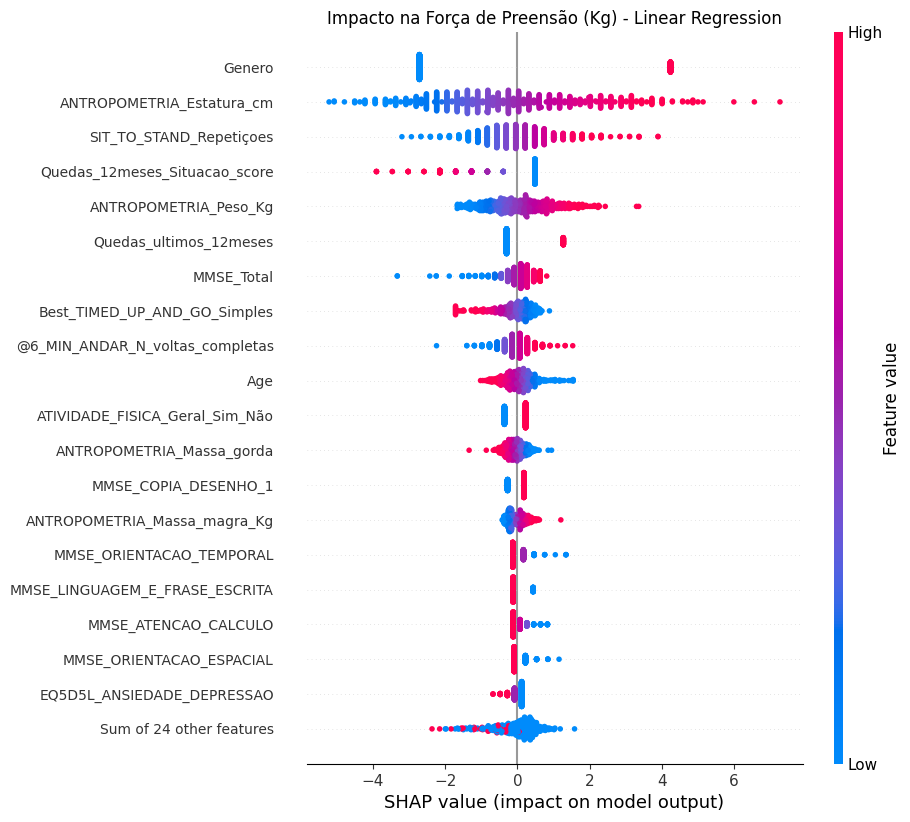


Top 5 Fatores que AUMENTAM a força:
                      feature  impact_kg
32                     Genero   6.957238
3   ANTROPOMETRIA_Estatura_cm   2.340542
33     Quedas_ultimos_12meses   1.571907
11    SIT_TO_STAND_Repetiçoes   1.102828
4       ANTROPOMETRIA_Peso_Kg   0.898590

Top 5 Fatores que DIMINUEM a força:
                                    feature  impact_kg
37  TIMED_UP_AND_GO_Simples_Auxiliar_marcha  -1.929085
30            Quedas_12meses_Situacao_score  -1.055087
36       TIMED_UP_AND_GO_Simples_Apoio_mãos  -0.801764
40                       @6_MIN_ANDAR_Parou  -0.693291
41           MMSE_LINGUAGEM_E_FRASE_ESCRITA  -0.552676


In [ ]:

import sklearn
from packaging.version import Version
from sklearn import __version__ as skver

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_absolute_error, r2_score

# Configuração do OneHotEncoder (compatibilidade de versões)
if Version(skver) >= Version("1.2"):
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
else:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

# ---- 1) Split (IMPORTANTE: Remover stratify para regressão)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, shuffle=True, random_state=42
)

# ---- 2) Column typing
num_all = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

binary_cols, continuous_cols = [], []
for c in num_all:
    vals = pd.Series(X_train[c]).dropna().unique()
    if set(np.unique(vals)).issubset({0, 1}):
        binary_cols.append(c)
    else:
        continuous_cols.append(c)

print(f"Continuous: {len(continuous_cols)} | Binary: {len(binary_cols)} | Categorical: {len(cat_cols)}")

# ---- 3) Preprocessor
pre = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler()), 
        ]), continuous_cols),
        ("bin", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
        ]), binary_cols),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("ohe", ohe),
        ]), cat_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# ---- 4) Model: Linear Regression
lin_reg = LinearRegression()

pipe = Pipeline([
    ("pre", pre),
    ("model", lin_reg),
])

pipe.fit(X_train, y_train)

# ---- 5) Avaliação Rápida
y_pred = pipe.predict(X_val)
mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print(f"\nResultados no Val Set:")
print(f"MAE (Erro Médio Absoluto): {mae:.2f} Kg")
print(f"R² (Explicação da Variância): {r2:.3f}")
print("-" * 30)

# ---- 6) SHAP
X_train_t = pipe.named_steps["pre"].transform(X_train)
X_val_t   = pipe.named_steps["pre"].transform(X_val)

try:
    feat_names = pipe.named_steps["pre"].get_feature_names_out().tolist()
except:
    feat_names = [f"f{i}" for i in range(X_train_t.shape[1])]

bg_idx = np.random.RandomState(42).choice(X_train_t.shape[0], size=min(500, X_train_t.shape[0]), replace=False)
background = X_train_t[bg_idx]

explainer = shap.LinearExplainer(pipe.named_steps["model"], background)
sv = explainer(X_val_t)

sv = shap.Explanation(
    values=sv.values,
    base_values=sv.base_values,
    data=pd.DataFrame(X_val_t, columns=feat_names),
    feature_names=feat_names,
)

plt.close("all")
fig, ax = plt.subplots(figsize=(14, 9))
shap.plots.beeswarm(sv, max_display=20, show=False)
plt.title("Impacto na Força de Preensão (Kg) - Linear Regression")
plt.yticks(fontsize=10)
plt.show()

# ---- 7) Coeficientes
coef = pipe.named_steps["model"].coef_.ravel()
coef_df = pd.DataFrame({"feature": feat_names, "impact_kg": coef})
print("\nTop 5 Fatores que AUMENTAM a força:")
print(coef_df.sort_values("impact_kg", ascending=False).head(5))
print("\nTop 5 Fatores que DIMINUEM a força:")
print(coef_df.sort_values("impact_kg", ascending=True).head(5))

=== Performance do Modelo (Handgrip) ===
R² Score : 0.468
MAE      : 3.73 Kg (Erro Médio Absoluto)
RMSE     : 5.33 Kg (Penaliza erros grandes)
MAPE     : 17.7 %  (Erro Médio Percentual)

Baseline (Média) MAE: 5.78 Kg
Ganho do Modelo     : 2.05 Kg de melhoria vs média


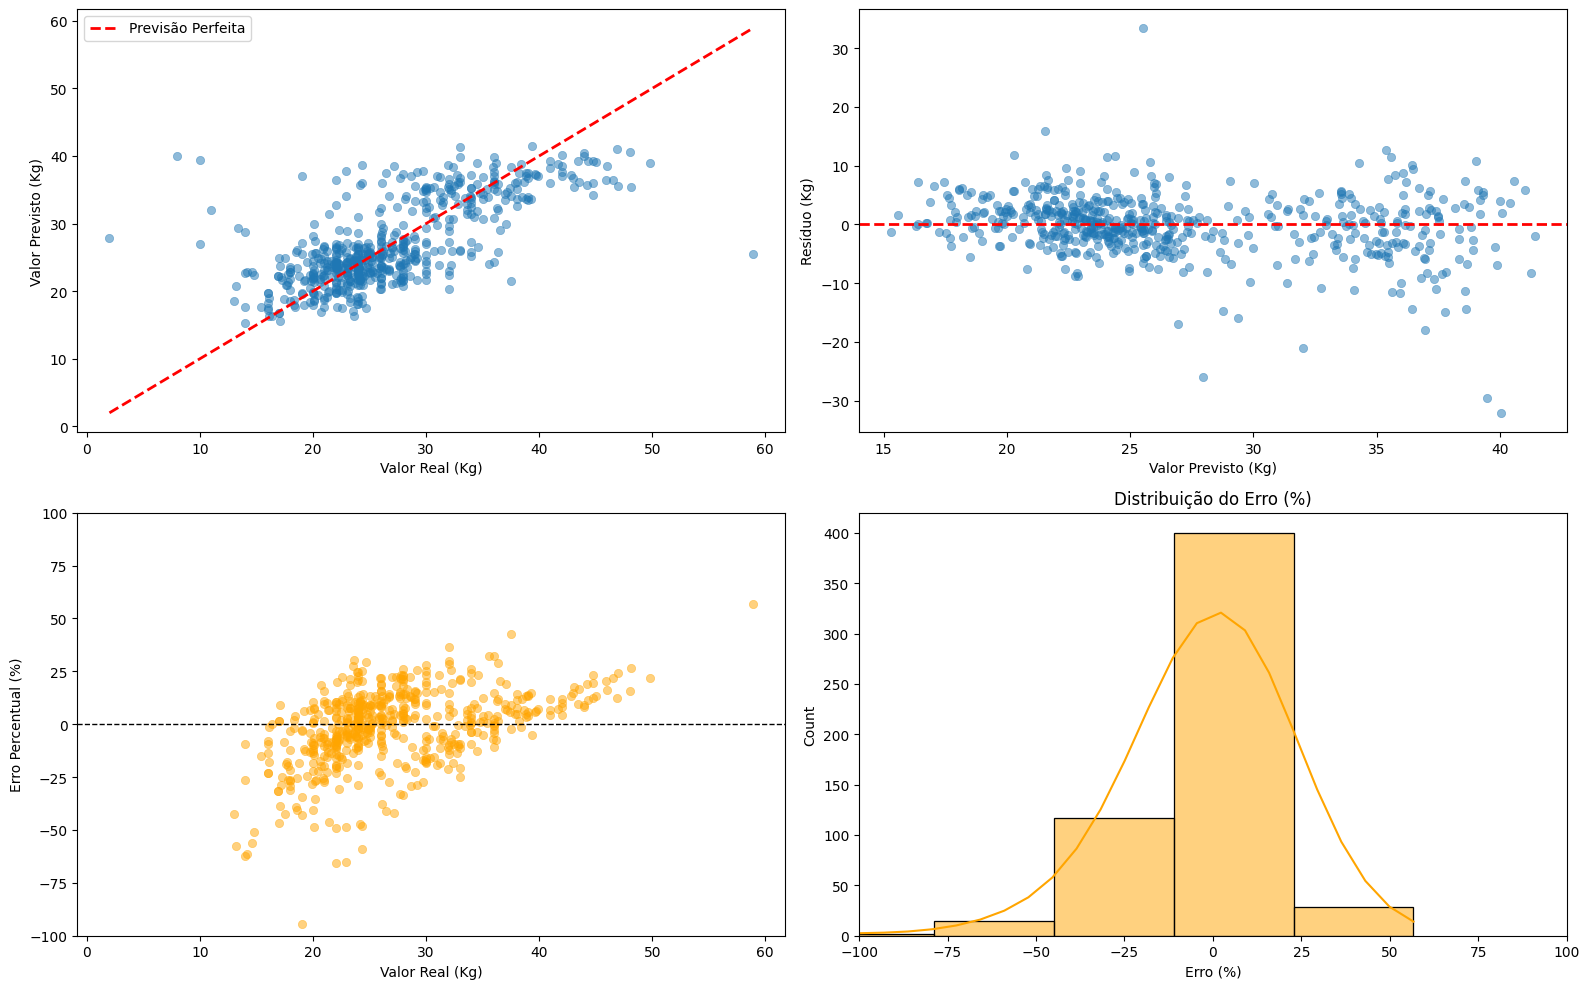

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Obter previsões
y_pred = pipe.predict(X_val)

# 2. Métricas de Regressão (Absolutas e Relativas)
mae = mean_absolute_error(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, y_pred)
# MAPE: Mean Absolute Percentage Error (Multiplicamos por 100 para ter %)
mape = mean_absolute_percentage_error(y_val, y_pred) * 100 

print(f"=== Performance do Modelo (Handgrip) ===")
print(f"R² Score : {r2:.3f}")
print(f"MAE      : {mae:.2f} Kg (Erro Médio Absoluto)")
print(f"RMSE     : {rmse:.2f} Kg (Penaliza erros grandes)")
print(f"MAPE     : {mape:.1f} %  (Erro Médio Percentual)") 
# Nota: Se o MAPE for 15%, significa que numa pessoa com 20kg de força, o modelo erra ~3kg.

# Comparar com a média simples (Baseline)
baseline_mae = mean_absolute_error(y_val, [y_train.mean()] * len(y_val))
print(f"\nBaseline (Média) MAE: {baseline_mae:.2f} Kg")
print(f"Ganho do Modelo     : {baseline_mae - mae:.2f} Kg de melhoria vs média")

# ---- 3. Gráficos de Diagnóstico ----
plt.figure(figsize=(16, 10))

# Plot A: Real vs Previsto
plt.subplot(2, 2, 1)
sns.scatterplot(x=y_val, y=y_pred, alpha=0.5, edgecolor=None)
min_val = min(y_val.min(), y_pred.min())
max_val = max(y_val.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Previsão Perfeita')
plt.xlabel("Valor Real (Kg)")
plt.ylabel("Valor Previsto (Kg)")
plt.legend()

# Plot B: Resíduos Absolutos (Kg)
residuos = y_val - y_pred
plt.subplot(2, 2, 2)
sns.scatterplot(x=y_pred, y=residuos, alpha=0.5, edgecolor=None)
plt.axhline(0, color='r', linestyle='--', lw=2)
plt.xlabel("Valor Previsto (Kg)")
plt.ylabel("Resíduo (Kg)")

# Plot C: Erro Percentual por Valor Real
# Ajuda a ver se o modelo erra mais (%) nos fracos ou nos fortes
erro_pct = (residuos / y_val) * 100
plt.subplot(2, 2, 3)
sns.scatterplot(x=y_val, y=erro_pct, alpha=0.5, color='orange', edgecolor=None)
plt.axhline(0, color='k', linestyle='--', lw=1)
plt.xlabel("Valor Real (Kg)")
plt.ylabel("Erro Percentual (%)")
# Limitar o eixo Y para evitar outliers extremos distorcerem o gráfico (ex: erro de 200%)
plt.ylim(-100, 100) 

# Plot D: Histograma do Erro Percentual
plt.subplot(2, 2, 4)
sns.histplot(erro_pct, kde=True, bins=40, color='orange')
plt.xlim(-100, 100) # Focamos na zona principal (-100% a +100%)
plt.title("Distribuição do Erro (%)")
plt.xlabel("Erro (%)")

plt.tight_layout()
plt.show()

[0]	train-mae:6.77453	val-mae:5.71886
[100]	train-mae:3.85863	val-mae:3.60687
[200]	train-mae:3.52394	val-mae:3.59312
[240]	train-mae:3.44822	val-mae:3.59738

Melhor iteração: 141
Melhor Score (MAE na validação): 3.5845 Kg

--- Performance Final ---
R² Score : 0.494
MAE      : 3.58 Kg
RMSE     : 5.20 Kg


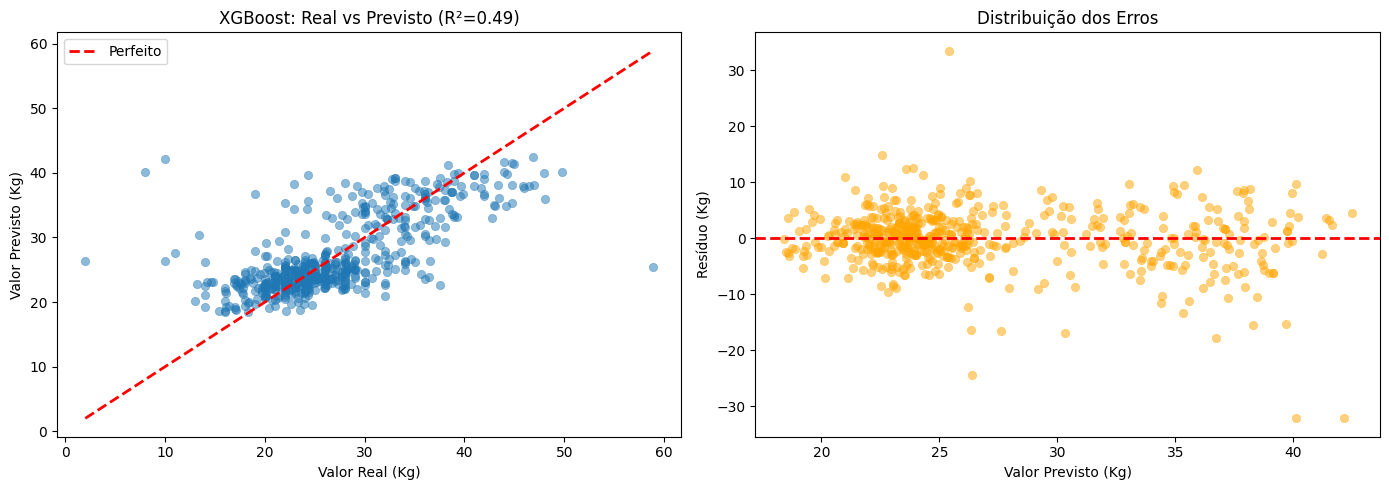

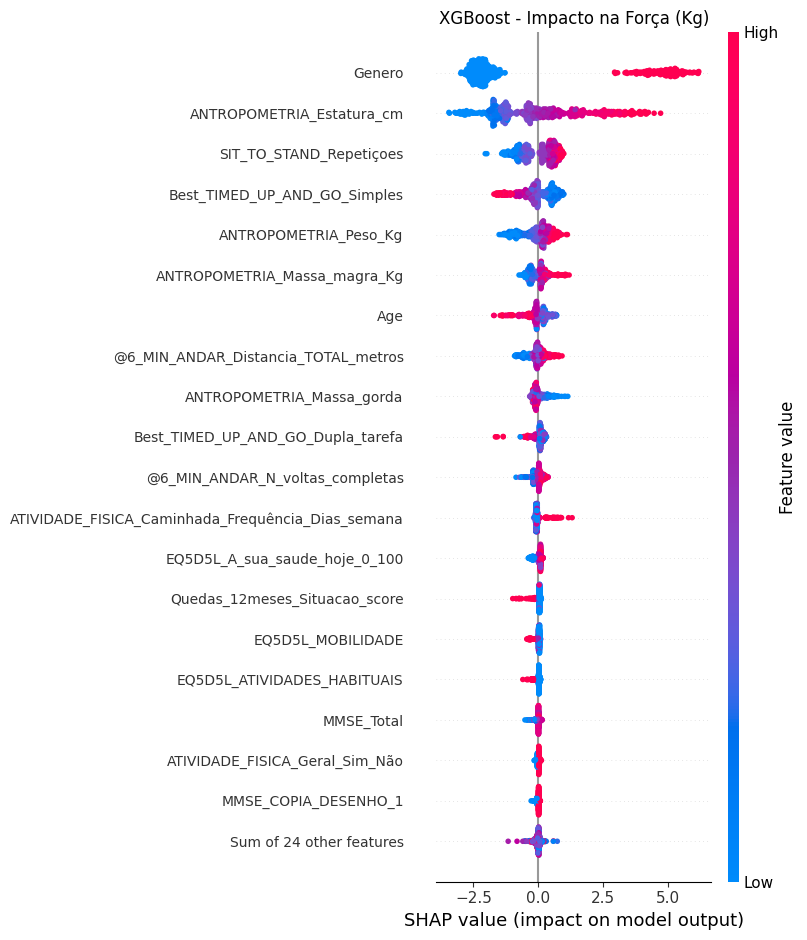

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn import __version__ as skver
from packaging.version import Version

import xgboost as xgb
import shap

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, shuffle=True, random_state=42
)

def make_ohe():
    if Version(skver) >= Version("1.2"):
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    else:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

pre = ColumnTransformer(
    transformers=[
        # XGBoost lida bem com missings, mas SimpleImputer garante que não há surpresas
        ("num", SimpleImputer(strategy="median"), num_cols),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("ohe", make_ohe()),
        ]), cat_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# Ajusta e transforma
X_train_t = pre.fit_transform(X_train)
X_val_t   = pre.transform(X_val)

# Recuperar nomes das features
try:
    feat_names = pre.get_feature_names_out().tolist()
except Exception:
    feat_names = [f"f{i}" for i in range(X_train_t.shape[1])]

dtrain = xgb.DMatrix(X_train_t, label=y_train, feature_names=feat_names)
dval   = xgb.DMatrix(X_val_t,   label=y_val,   feature_names=feat_names)

params = {
    "objective": "reg:squarederror", # <--- MUDANÇA CRUCIAL: Regressão
    "eval_metric": "mae",            # Otimizar o erro médio absoluto (Kg)
    "eta": 0.02,                     # Learning rate baixo para ser preciso
    "max_depth": 4,                  # Evitar overfitting em datasets pequenos
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_lambda": 1.0,
    "min_child_weight": 3.0,         # Um pouco mais alto para evitar folhas com poucos alunos
    "tree_method": "hist",
    "seed": 42,
    # "scale_pos_weight": REMOVIDO (não se usa em regressão)
}

bst = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=2000,
    evals=[(dtrain, "train"), (dval, "val")],
    early_stopping_rounds=100,       # Para se o erro na validação não baixar
    verbose_eval=100                 # Imprime a cada 100 iterações
)

print(f"\nMelhor iteração: {bst.best_iteration}")
print(f"Melhor Score (MAE na validação): {bst.best_score:.4f} Kg")


y_pred = bst.predict(dval, iteration_range=(0, bst.best_iteration + 1))

mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2 = r2_score(y_val, y_pred)

print("\n--- Performance Final ---")
print(f"R² Score : {r2:.3f}")
print(f"MAE      : {mae:.2f} Kg")
print(f"RMSE     : {rmse:.2f} Kg")


plt.figure(figsize=(14, 5))

# Plot A: Real vs Previsto
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_val, y=y_pred, alpha=0.5, edgecolor=None)
min_val = min(y_val.min(), y_pred.min())
max_val = max(y_val.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfeito')
plt.xlabel("Valor Real (Kg)")
plt.ylabel("Valor Previsto (Kg)")
plt.title(f"XGBoost: Real vs Previsto (R²={r2:.2f})")
plt.legend()

# Plot B: Resíduos
residuos = y_val - y_pred
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_pred, y=residuos, alpha=0.5, edgecolor=None, color='orange')
plt.axhline(0, color='r', linestyle='--', lw=2)
plt.xlabel("Valor Previsto (Kg)")
plt.ylabel("Resíduo (Kg)")
plt.title("Distribuição dos Erros")
plt.tight_layout()
plt.show()


try:
    bst.set_attr(base_score=str(np.mean(y_train))) 
except:
    pass

bg_idx = np.random.choice(X_train_t.shape[0], size=min(1000, X_train_t.shape[0]), replace=False)

try:
    # TreeExplainer é o ideal para XGBoost
    explainer = shap.TreeExplainer(bst, data=X_train_t[bg_idx], feature_names=feat_names)
    sv = explainer(X_val_t, check_additivity=False)
except Exception as e:
    print(f"TreeExplainer falhou ({e}), usando fallback...")
    explainer = shap.Explainer(bst, X_train_t[bg_idx], feature_names=feat_names)
    sv = explainer(X_val_t)

# Objeto Explanation formatado
sv_formatted = shap.Explanation(
    values=sv.values,
    base_values=sv.base_values,
    data=pd.DataFrame(X_val_t, columns=feat_names),
    feature_names=feat_names
)

plt.close("all")
fig, ax = plt.subplots(figsize=(12, 10))
shap.plots.beeswarm(sv_formatted, max_display=20, show=False)
plt.title("XGBoost - Impacto na Força (Kg)")
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

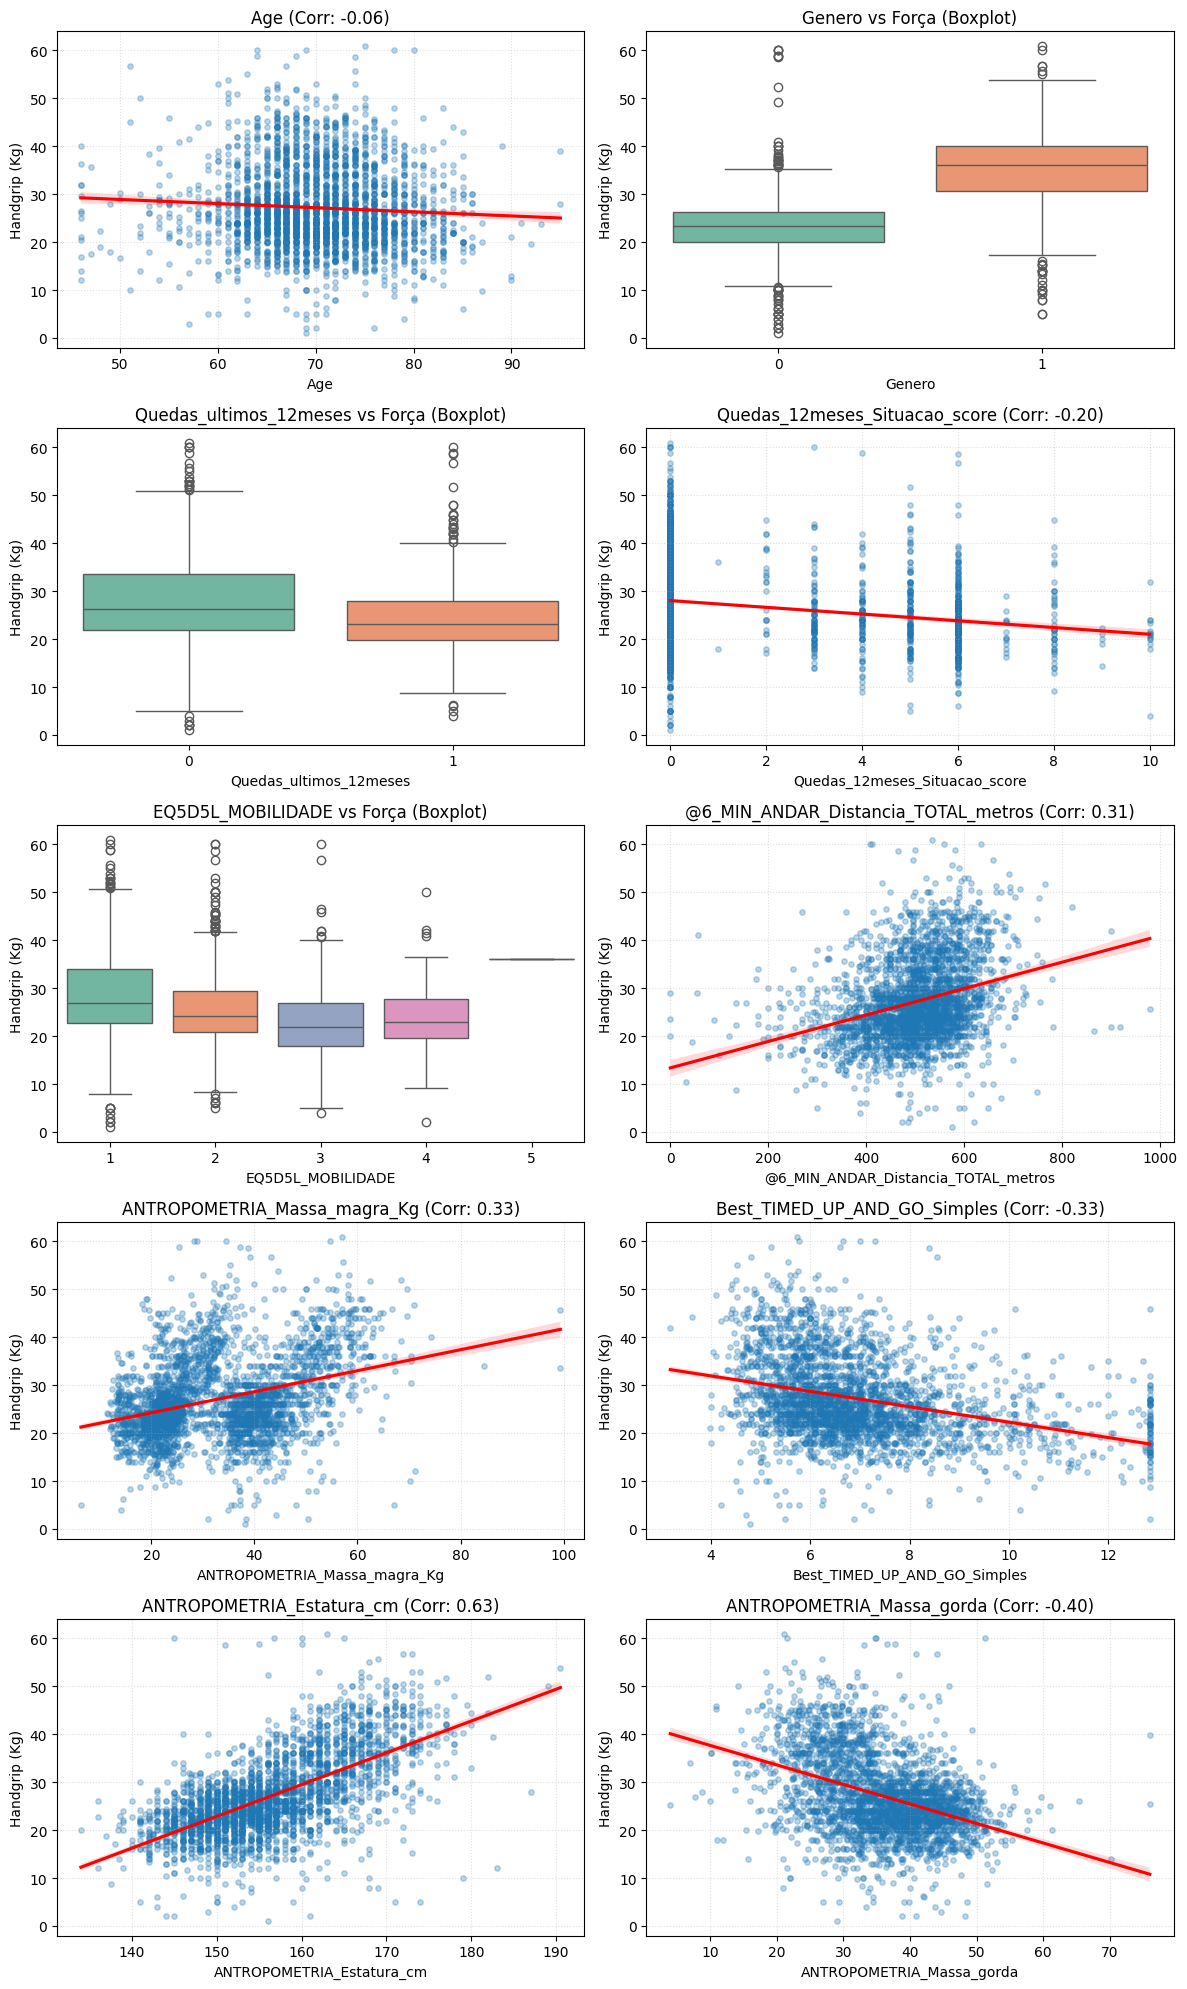

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- configurações ---
TARGET = "HANDGRIP_BEST"

# Lista de features sugerida para ver a correlação com a força
features = [
    "Age",
    "Genero",                        # Categórica (0/1)
    "Quedas_ultimos_12meses",        # Agora é feature!
    "Quedas_12meses_Situacao_score", # Feature do LLM
    "EQ5D5L_MOBILIDADE",             # Categórica (1 a 5)
    "@6_MIN_ANDAR_Distancia_TOTAL_metros",
    "ANTROPOMETRIA_Massa_magra_Kg",
    "Best_TIMED_UP_AND_GO_Simples",
    "ANTROPOMETRIA_Estatura_cm",
    "ANTROPOMETRIA_Massa_gorda",
]

# Garante que existem no DataFrame (filtra as que não existem para não dar erro)
features = [f for f in features if f in df.columns]
assert TARGET in df.columns, f"Coluna alvo {TARGET} não encontrada"

def is_binary_or_categorical(series: pd.Series) -> bool:
    # Trata como categórica se não for numérica OU se tiver <= 10 valores distintos
    # (Ex: Genero, Quedas, Escolaridade, EQ5D)
    if not pd.api.types.is_numeric_dtype(series):
        return True
    vals = pd.unique(series.dropna())
    return len(vals) <= 10 and np.all(np.isfinite(vals))

n = len(features)
ncols = 2
nrows = int(np.ceil(n / ncols))

plt.figure(figsize=(12, 4 * nrows))

for i, col in enumerate(features, 1):
    ax = plt.subplot(nrows, ncols, i)
    
    # Dados limpos para plotagem (remove NaNs apenas destas duas colunas)
    temp_df = df[[col, TARGET]].dropna()
    
    if is_binary_or_categorical(df[col]):
        # === Categórica vs Numérica (Boxplot) ===
        # Mostra a distribuição da Força (Y) para cada categoria (X)
        sns.boxplot(x=col, y=TARGET, data=temp_df, ax=ax, palette="Set2")
        
        # Opcional: Adicionar os pontos por cima para ver a densidade
        # sns.stripplot(x=col, y=TARGET, data=temp_df, color='black', alpha=0.1, size=2, ax=ax)
        
        ax.set_title(f"{col} vs Força (Boxplot)")
        ax.set_xlabel(col)
        ax.set_ylabel("Handgrip (Kg)")
        
    else:
        # === Numérica vs Numérica (Scatter Plot + Regressão) ===
        # Mostra a correlação. A linha mostra a tendência.
        sns.regplot(
            x=col, 
            y=TARGET, 
            data=temp_df, 
            ax=ax, 
            scatter_kws={'alpha': 0.3, 's': 15}, # Pontos transparentes
            line_kws={'color': 'red'}            # Linha de tendência vermelha
        )
        
        # Calcular correlação para por no título
        corr = temp_df[col].corr(temp_df[TARGET])
        ax.set_title(f"{col} (Corr: {corr:.2f})")
        ax.set_xlabel(col)
        ax.set_ylabel("Handgrip (Kg)")
        ax.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

## Handgrip Regresssion with tresholds

0:	learn: 6.7739994	test: 5.7108092	best: 5.7108092 (0)	total: 3.18ms	remaining: 6.36s
100:	learn: 4.1131320	test: 3.6489034	best: 3.6489034 (100)	total: 147ms	remaining: 2.76s
200:	learn: 3.7997242	test: 3.5942766	best: 3.5888387 (165)	total: 276ms	remaining: 2.47s
300:	learn: 3.6641955	test: 3.5795501	best: 3.5793907 (298)	total: 405ms	remaining: 2.29s
400:	learn: 3.5611825	test: 3.5731541	best: 3.5699397 (396)	total: 536ms	remaining: 2.14s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 3.569939702
bestIteration = 396

Shrink model to first 397 iterations.

Melhor iteração: 396
Melhor Score (MAE): 3.5699 Kg

--- Performance Final ---
R² Score : 0.488
MAE      : 3.57 Kg
RMSE     : 5.23 Kg


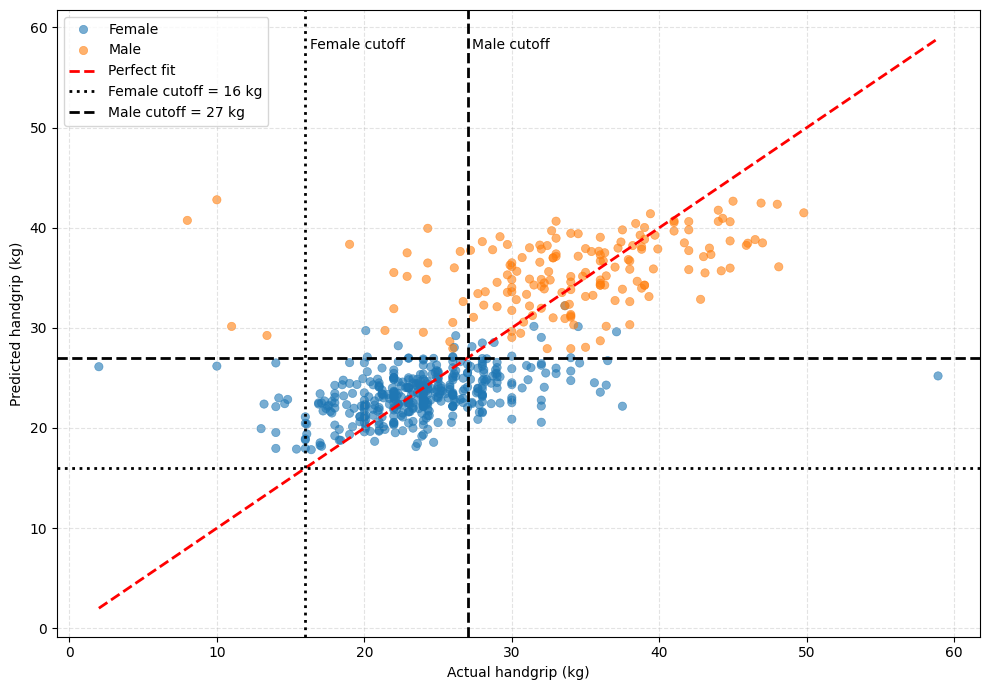

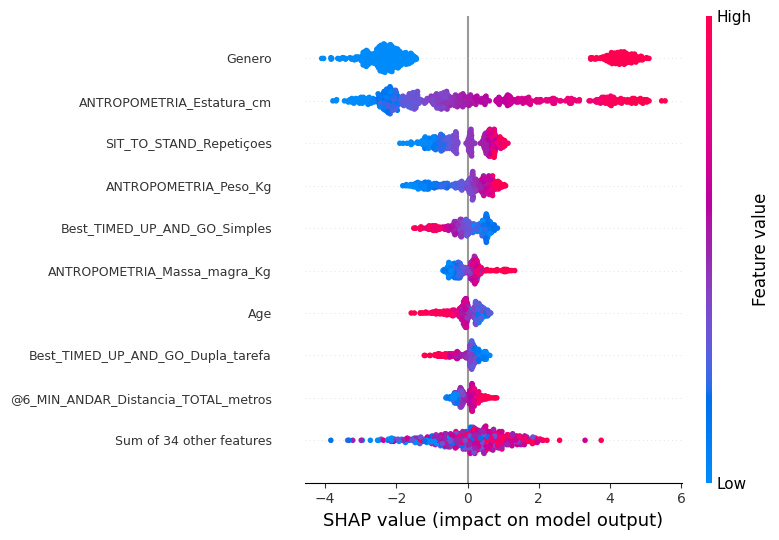

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Standard Sklearn imports
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn import __version__ as skver
from packaging.version import Version

# specific imports
from catboost import CatBoostRegressor, Pool
import shap

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, shuffle=True, random_state=42
)


def make_ohe():
    if Version(skver) >= Version("1.2"):
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    else:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

pre = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), num_cols),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("ohe", make_ohe()),
        ]), cat_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# Fit and transform
X_train_t = pre.fit_transform(X_train)
X_val_t   = pre.transform(X_val)

# Get feature names for SHAP
try:
    feat_names = pre.get_feature_names_out().tolist()
except Exception:
    feat_names = [f"f{i}" for i in range(X_train_t.shape[1])]


model = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.02, # Um pouco mais lento para ser preciso
    depth=6,            # Profundidade padrão (6 é um bom equilíbrio)
    loss_function='RMSE',
    eval_metric='MAE',  # Otimizar o erro médio absoluto (Kg)
    early_stopping_rounds=100,
    verbose=100,        # Imprime a cada 100 iterações
    random_seed=42,
    allow_writing_files=False # Evita criar pastas catboost_info no disco
)

# Treino com Early Stopping
model.fit(
    X_train_t, y_train,
    eval_set=(X_val_t, y_val),
    use_best_model=True
)

print(f"\nMelhor iteração: {model.get_best_iteration()}")
print(f"Melhor Score (MAE): {model.get_best_score()['validation']['MAE']:.4f} Kg")


y_pred = model.predict(X_val_t)

mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2 = r2_score(y_val, y_pred)

print("\n--- Performance Final ---")
print(f"R² Score : {r2:.3f}")
print(f"MAE      : {mae:.2f} Kg")
print(f"RMSE     : {rmse:.2f} Kg")

# =======================
# 4A) Actual vs Predicted — split by sex + sarcopenia cutoffs
# =======================

# --- 1) Get sex column robustly ---
sex_col = None
for c in ["Genero", "Género", "gender", "Sex", "sexo", "SEXO"]:
    if c in X_val.columns:
        sex_col = c
        break
if sex_col is None:
    raise ValueError("Could not find sex/gender column in X_val. Rename or add it (e.g., 'Genero').")

sex_raw = X_val[sex_col].astype(str).str.strip().str.lower()

# Map common PT/EN encodings -> {Male, Female}
def _map_sex(s: str) -> str:
    if s in ["m", "male", "masc", "masculino", "homem"]:
        return "Male"
    if s in ["f", "female", "fem", "feminino", "mulher"]:
        return "Female"
    return "Other/Unknown"

sex_std = sex_raw.map(_map_sex)

plot_df = pd.DataFrame({
    "Actual": np.asarray(y_val),
    "Predicted": np.asarray(y_pred),
    "Sex": sex_std.values
}).dropna(subset=["Actual", "Predicted"])

# --- 2) Define sarcopenia cutoffs (edit if you use different criteria) ---
CUT_MALE = 27.0
CUT_FEMALE = 16.0
cut_map = {"Male": CUT_MALE, "Female": CUT_FEMALE}


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1) Get sex column robustly ---
sex_col = None
for c in ["Genero", "Género", "gender", "Sex", "sexo", "SEXO"]:
    if c in X_val.columns:
        sex_col = c
        break
if sex_col is None:
    raise ValueError("Could not find sex/gender column in X_val. Rename or add it (e.g., 'Genero').")

sex_raw = X_val[sex_col].astype(str).str.strip().str.lower()

def _map_sex(s: str) -> str:
    if s in ["1"]:
        return "Male"
    if s in ["f", "female", "fem", "feminino", "mulher","0"]:
        return "Female"
    return "Other/Unknown"

sex_std = sex_raw.map(_map_sex)

plot_df = pd.DataFrame({
    "Actual": np.asarray(y_val),
    "Predicted": np.asarray(y_pred),
    "Sex": sex_std.values
}).dropna(subset=["Actual", "Predicted"])

# --- 2) Sarcopenia cutoffs (edit if you use different criteria) ---
CUT_MALE = 27.0
CUT_FEMALE = 16.0

# --- 3) Plot (single axis) ---
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=plot_df, x="Actual", y="Predicted",
    hue="Sex", alpha=0.6, edgecolor=None
)

# Perfect fit line
min_v = min(plot_df["Actual"].min(), plot_df["Predicted"].min())
max_v = max(plot_df["Actual"].max(), plot_df["Predicted"].max())
plt.plot([min_v, max_v], [min_v, max_v], "r--", lw=2, label="Perfect fit")

# Female cutoff (dotted)
plt.axvline(CUT_FEMALE, color="black", linestyle=":", lw=2, label=f"Female cutoff = {CUT_FEMALE:.0f} kg")
plt.axhline(CUT_FEMALE, color="black", linestyle=":", lw=2)

# Male cutoff (dashed)
plt.axvline(CUT_MALE, color="black", linestyle="--", lw=2, label=f"Male cutoff = {CUT_MALE:.0f} kg")
plt.axhline(CUT_MALE, color="black", linestyle="--", lw=2)

# Small annotations (optional but helps readability)
plt.text(CUT_FEMALE + 0.3, max_v, "Female cutoff", va="top")
plt.text(CUT_MALE + 0.3, max_v, "Male cutoff", va="top")


plt.xlabel("Actual handgrip (kg)")
plt.ylabel("Predicted handgrip (kg)")
plt.grid(True, linestyle="--", alpha=0.35)
plt.legend(loc="best")
plt.tight_layout()
plt.show()

explainer = shap.TreeExplainer(model)
sv = explainer(X_val_t)

sv_formatted = shap.Explanation(
    values=sv.values,
    base_values=sv.base_values,
    data=pd.DataFrame(X_val_t, columns=feat_names),
    feature_names=feat_names
)

plt.close("all")
plt.figure(figsize=(12, 7))
shap.plots.beeswarm(sv_formatted, max_display=10, show=False)  # <-- TOP 10
plt.yticks(fontsize=9)
plt.xticks(fontsize=10)
plt.subplots_adjust(left=0.40)
plt.tight_layout()
plt.show()


## Study of Error by gender



=== ANÁLISE DE ERRO: Por Género ===

Género 0 (Mulheres?) (n=404):
  -> Força Média:      23.83 Kg
  -> MAE (Erro):       3.04 Kg
  -> Viés:             -0.4850 Kg
  -> Erro Relativo:    12.8%

Género 1 (Homens?) (n=165):
  -> Força Média:      34.17 Kg
  -> MAE (Erro):       4.87 Kg
  -> Viés:             1.4601 Kg
  -> Erro Relativo:    14.3%


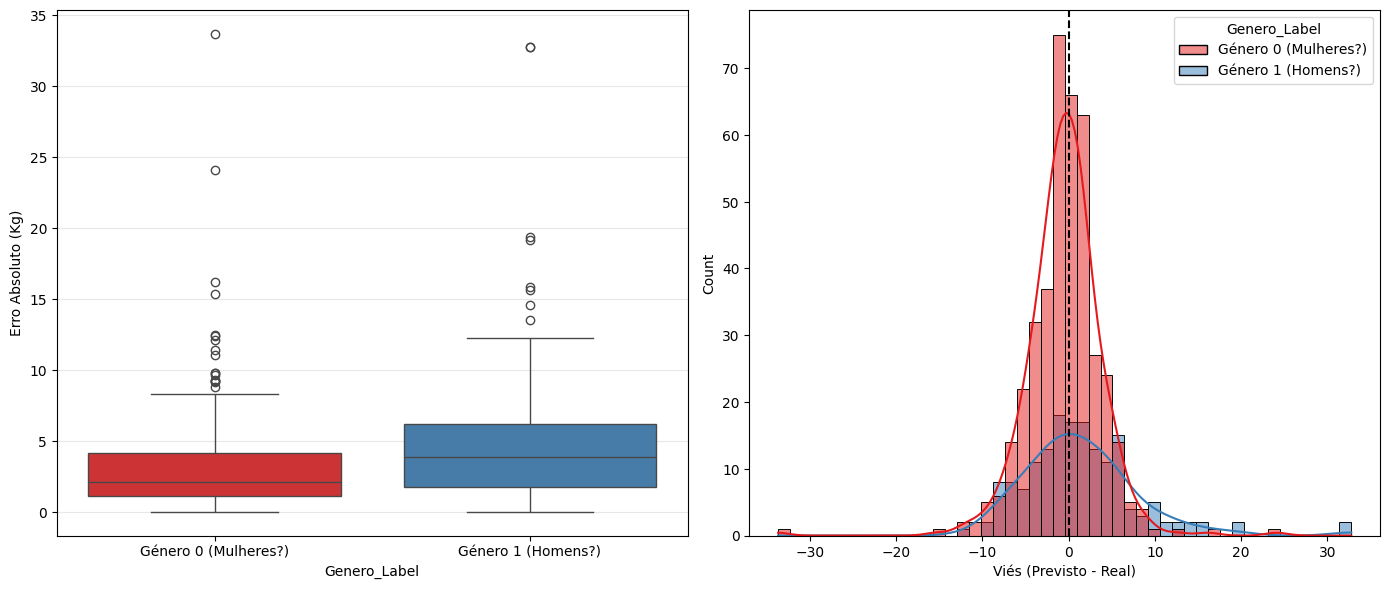

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error

# 1. Garantir previsões e forçar formato 1D
y_pred = model.predict(X_val_t)
y_pred = np.array(y_pred).ravel()  # <--- CORREÇÃO: Força 1D
y_val_flat = np.array(y_val).ravel() # <--- CORREÇÃO: Força 1D

# 2. Recuperar a coluna 'Genero'
try:
    # Tenta pelo índice original
    genero_val = df.loc[X_val.index, 'Genero']
except:
    # Fallback para o X_val
    genero_val = X_val['Genero']

# Forçar Genero a ser 1D também (caso haja duplicados)
genero_val_flat = np.array(genero_val).ravel()

# Verificação de segurança (Tamanhos têm de bater certo)
if len(genero_val_flat) != len(y_val_flat):
    print(f"ERRO DE TAMANHO: Genero tem {len(genero_val_flat)} linhas, mas y_val tem {len(y_val_flat)}.")
    # Truque: Se o X_val for um array transformado (numpy), perdemos o índice.
    # Assumimos que a ordem se mantém se não houve baralhação extra.
    print("A usar Genero do X_val diretamente...")
    genero_val_flat = X_val['Genero'].values.ravel()

# 3. Criar DataFrame (Agora seguro com tudo em 1D)
df_error_gen = pd.DataFrame({
    'Genero_Code': genero_val_flat,
    'Real (Kg)': y_val_flat,
    'Previsto (Kg)': y_pred,
    'Erro Absoluto (Kg)': np.abs(y_val_flat - y_pred),
    'Viés (Previsto - Real)': (y_pred - y_val_flat)
})

# Mapear códigos
map_gen = {0: 'Género 0 (Mulheres?)', 1: 'Género 1 (Homens?)'}
df_error_gen['Genero_Label'] = df_error_gen['Genero_Code'].map(map_gen)

# 4. Estatísticas
print(f"\n=== ANÁLISE DE ERRO: Por Género ===")
grupos = np.unique(df_error_gen['Genero_Code'])
grupos.sort()

for g in grupos:
    subset = df_error_gen[df_error_gen['Genero_Code'] == g]
    mae = mean_absolute_error(subset['Real (Kg)'], subset['Previsto (Kg)'])
    bias = np.mean(subset['Viés (Previsto - Real)'])
    mean_force = np.mean(subset['Real (Kg)'])
    
    label = map_gen.get(g, f"Genero {g}")
    print(f"\n{label} (n={len(subset)}):")
    print(f"  -> Força Média:      {mean_force:.2f} Kg")
    print(f"  -> MAE (Erro):       {mae:.2f} Kg")
    print(f"  -> Viés:             {bias:.4f} Kg")
    print(f"  -> Erro Relativo:    {(mae/mean_force)*100:.1f}%")

# 5. Visualização
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.boxplot(x='Genero_Label', y='Erro Absoluto (Kg)', data=df_error_gen, palette="Set1")
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
sns.histplot(data=df_error_gen, x='Viés (Previsto - Real)', hue='Genero_Label', kde=True, palette="Set1")
plt.axvline(0, color='k', linestyle='--')

plt.tight_layout()
plt.show()

## EBM regressor

Training EBM Regressor... (Pode demorar um pouco, ele calcula interações)

--- Performance Final (EBM) ---
R² Score : 0.478
MAE      : 3.59 Kg
RMSE     : 5.28 Kg


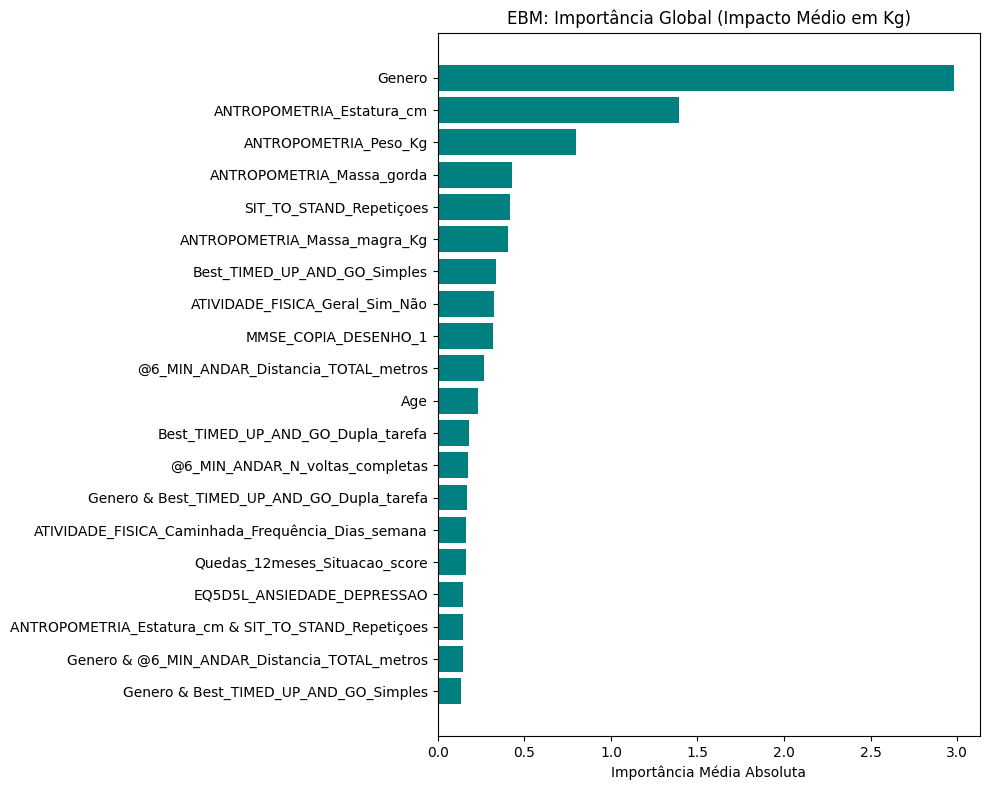

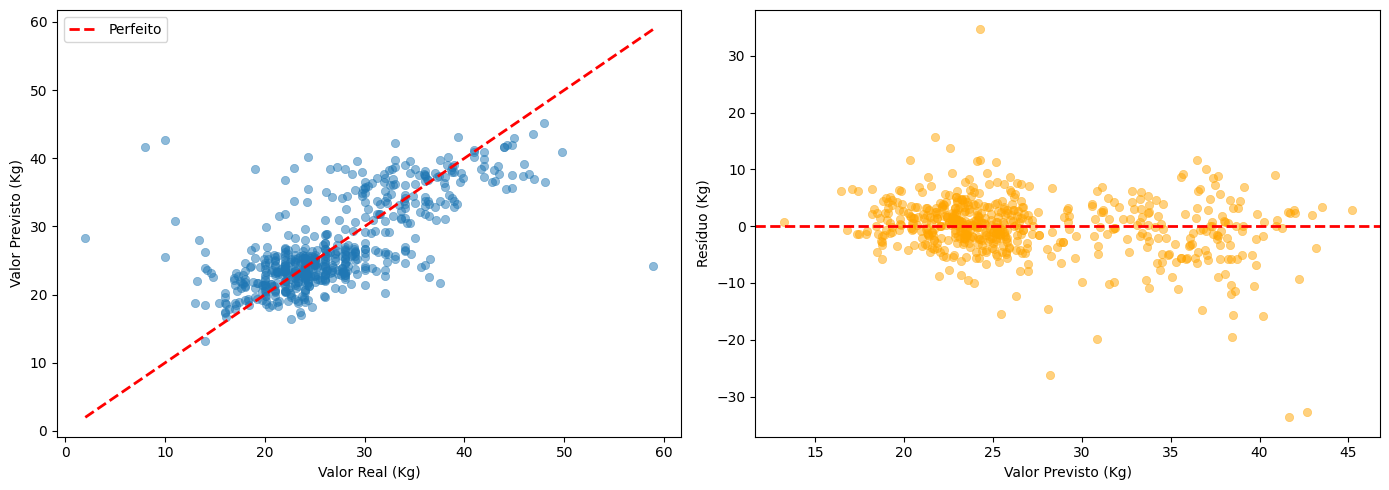

In [ ]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn import __version__ as skver
from packaging.version import Version

# EBM Imports (Agora Regressor)
from interpret.glassbox import ExplainableBoostingRegressor
from interpret import show


X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, shuffle=True, random_state=42
)


def make_ohe():
    if Version(skver) >= Version("1.2"):
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    else:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

pre = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), num_cols),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("ohe", make_ohe()),
        ]), cat_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# Fit and transform
X_train_t = pre.fit_transform(X_train)
X_val_t   = pre.transform(X_val)

# Get feature names (CRUCIAL para o EBM desenhar os gráficos certos)
try:
    feat_names = pre.get_feature_names_out().tolist()
except Exception:
    feat_names = [f"f{i}" for i in range(X_train_t.shape[1])]


print("Training EBM Regressor... (Pode demorar um pouco, ele calcula interações)")

ebm = ExplainableBoostingRegressor(
    feature_names=feat_names,
    interactions=10,       # Deteta automaticamente as 10 interações mais fortes (ex: Idade x Genero)
    outer_bags=8,          # Suaviza as curvas
    inner_bags=0,
    learning_rate=0.01, 
    max_rounds=2000, 
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1              # Usa todos os cores do CPU
)

ebm.fit(X_train_t, y_train)


y_pred = ebm.predict(X_val_t)

mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2 = r2_score(y_val, y_pred)

print("\n--- Performance Final (EBM) ---")
print(f"R² Score : {r2:.3f}")
print(f"MAE      : {mae:.2f} Kg")
print(f"RMSE     : {rmse:.2f} Kg")



ebm_global = ebm.explain_global()

# Extrair dados para plot estático
data = ebm_global.data()
importances = data['scores']
names = data['names']

# Ordenar por importância
imp_df = pd.DataFrame({'feature': names, 'importance': importances})
imp_df = imp_df.sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
plt.barh(imp_df['feature'], imp_df['importance'], color='teal')
plt.gca().invert_yaxis()
plt.title("EBM: Importância Global (Impacto Médio em Kg)")
plt.xlabel("Importância Média Absoluta")
plt.tight_layout()
plt.show()

# =======================
# 5) Gráficos de Diagnóstico
# =======================
plt.figure(figsize=(14, 5))

# Plot A: Real vs Previsto
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_val, y=y_pred, alpha=0.5, edgecolor=None)
min_val = min(y_val.min(), y_pred.min())
max_val = max(y_val.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfeito')
plt.xlabel("Valor Real (Kg)")
plt.ylabel("Valor Previsto (Kg)")
plt.legend()

# Plot B: Resíduos
residuos = y_val - y_pred
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_pred, y=residuos, alpha=0.5, edgecolor=None, color='orange')
plt.axhline(0, color='r', linestyle='--', lw=2)
plt.xlabel("Valor Previsto (Kg)")
plt.ylabel("Resíduo (Kg)")
plt.tight_layout()
plt.show()



# SVM



Training SVR (RBF)...

--- Performance Final (SVR) ---
R² Score : 0.456
MAE      : 3.76 Kg
RMSE     : 5.39 Kg


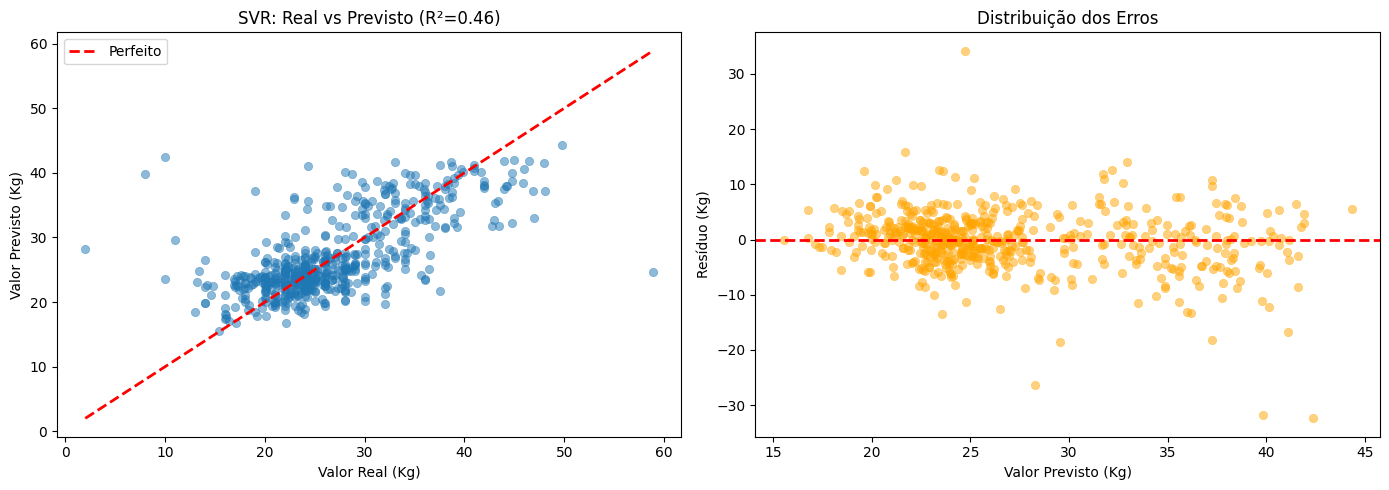


Calculating SHAP values (KernelExplainer is slow)...


100%|██████████| 100/100 [01:59<00:00,  1.20s/it]


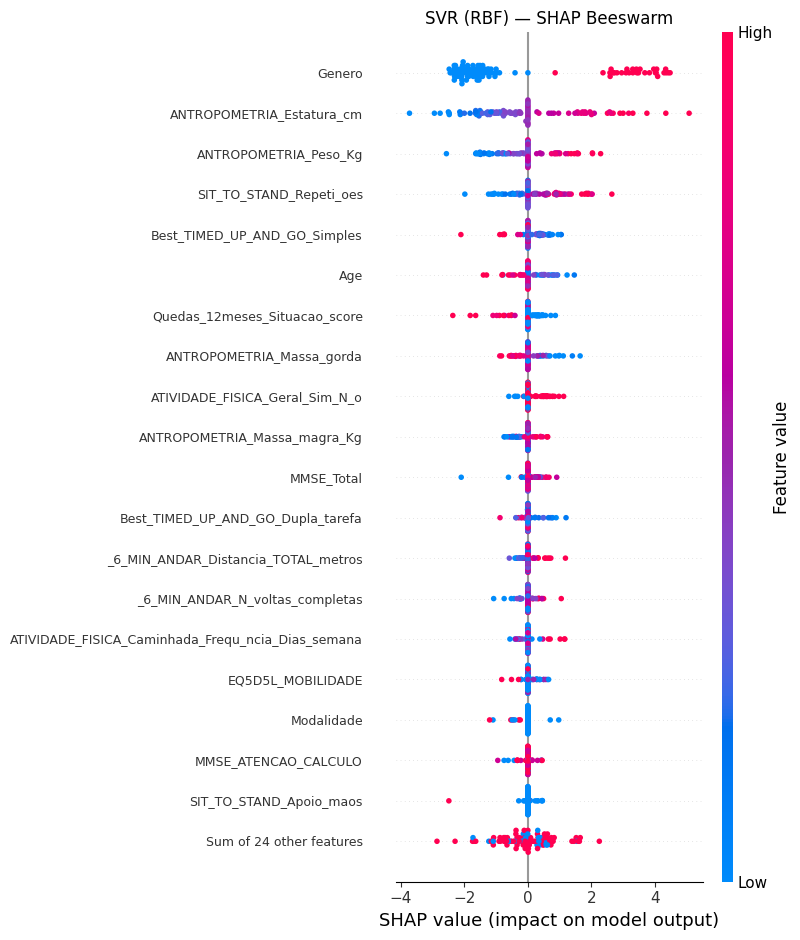

In [ ]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Model
from sklearn.svm import SVR # <--- Importante: SVR é para Regressão

# Preprocessing & Metrics
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn import __version__ as skver
from packaging.version import Version

import shap

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, shuffle=True, random_state=42
)


def make_ohe():
    if Version(skver) >= Version("1.2"):
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    else:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

pre = ColumnTransformer(
    transformers=[
        # SVR falha miseravelmente se os dados não estiverem na escala certa (StandardScaler)
        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()) 
        ]), num_cols),
        
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("ohe", make_ohe()),
        ]), cat_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# Fit and Transform
X_train_t = pre.fit_transform(X_train)
X_val_t   = pre.transform(X_val)

# Clean Feature Names
try:
    raw_names = pre.get_feature_names_out().tolist()
except:
    raw_names = [f"f{i}" for i in range(X_train_t.shape[1])]

clean_names = [re.sub(r'[^A-Za-z0-9_]+', '_', n) for n in raw_names]

# DataFrames for SHAP
X_train_df = pd.DataFrame(X_train_t, columns=clean_names)
X_val_df   = pd.DataFrame(X_val_t, columns=clean_names)

# 2) Train SVR (RBF Kernel)
print("Training SVR (RBF)...")
# C=1.0: Penalização de erro (Maior = menos tolerante, risco overfitting)
# epsilon=0.1: Margem de tolerância onde erros pequenos são ignorados
model_svr = SVR(kernel='rbf', C=10.0, epsilon=0.1) # C=10 costuma funcionar melhor em regressão complexa
model_svr.fit(X_train_df, y_train)

# 3) Metrics of Regression
y_pred = model_svr.predict(X_val_df)

mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2 = r2_score(y_val, y_pred)

print("\n--- Performance Final (SVR) ---")
print(f"R² Score : {r2:.3f}")
print(f"MAE      : {mae:.2f} Kg")
print(f"RMSE     : {rmse:.2f} Kg")

# 4) Gráficos de Diagnóstico
plt.figure(figsize=(14, 5))

# Plot A: Real vs Previsto
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_val, y=y_pred, alpha=0.5, edgecolor=None)
min_val = min(y_val.min(), y_pred.min())
max_val = max(y_val.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfeito')
plt.title(f"SVR: Real vs Previsto (R²={r2:.2f})")
plt.xlabel("Valor Real (Kg)")
plt.ylabel("Valor Previsto (Kg)")
plt.legend()

# Plot B: Resíduos
residuos = y_val - y_pred
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_pred, y=residuos, alpha=0.5, edgecolor=None, color='orange')
plt.axhline(0, color='r', linestyle='--', lw=2)
plt.title("Distribuição dos Erros")
plt.xlabel("Valor Previsto (Kg)")
plt.ylabel("Resíduo (Kg)")
plt.tight_layout()
plt.show()

# 5) SHAP Beeswarm (KernelExplainer)
print("\nCalculating SHAP values (KernelExplainer is slow)...")

# Amostra do background (treino)
background_data = shap.sample(X_train_df, 50, random_state=42) # Reduzi para 50 para ser mais rápido

# Explainer genérico
explainer = shap.KernelExplainer(model_svr.predict, background_data)

# Explicação (Usamos apenas 100 amostras da validação para não demorar uma eternidade)
shap_vals = explainer.shap_values(X_val_df.iloc[:100], nsamples=100) 

sv = shap.Explanation(
    values=shap_vals,
    base_values=explainer.expected_value,
    data=X_val_df.iloc[:100],
    feature_names=clean_names
)

plt.close("all")
fig, ax = plt.subplots(figsize=(12, 10))
shap.plots.beeswarm(sv, max_display=20, show=False)
plt.yticks(fontsize=9)
plt.title("SVR (RBF) — SHAP Beeswarm")
plt.tight_layout()
plt.show()

## Clinical validation per gender

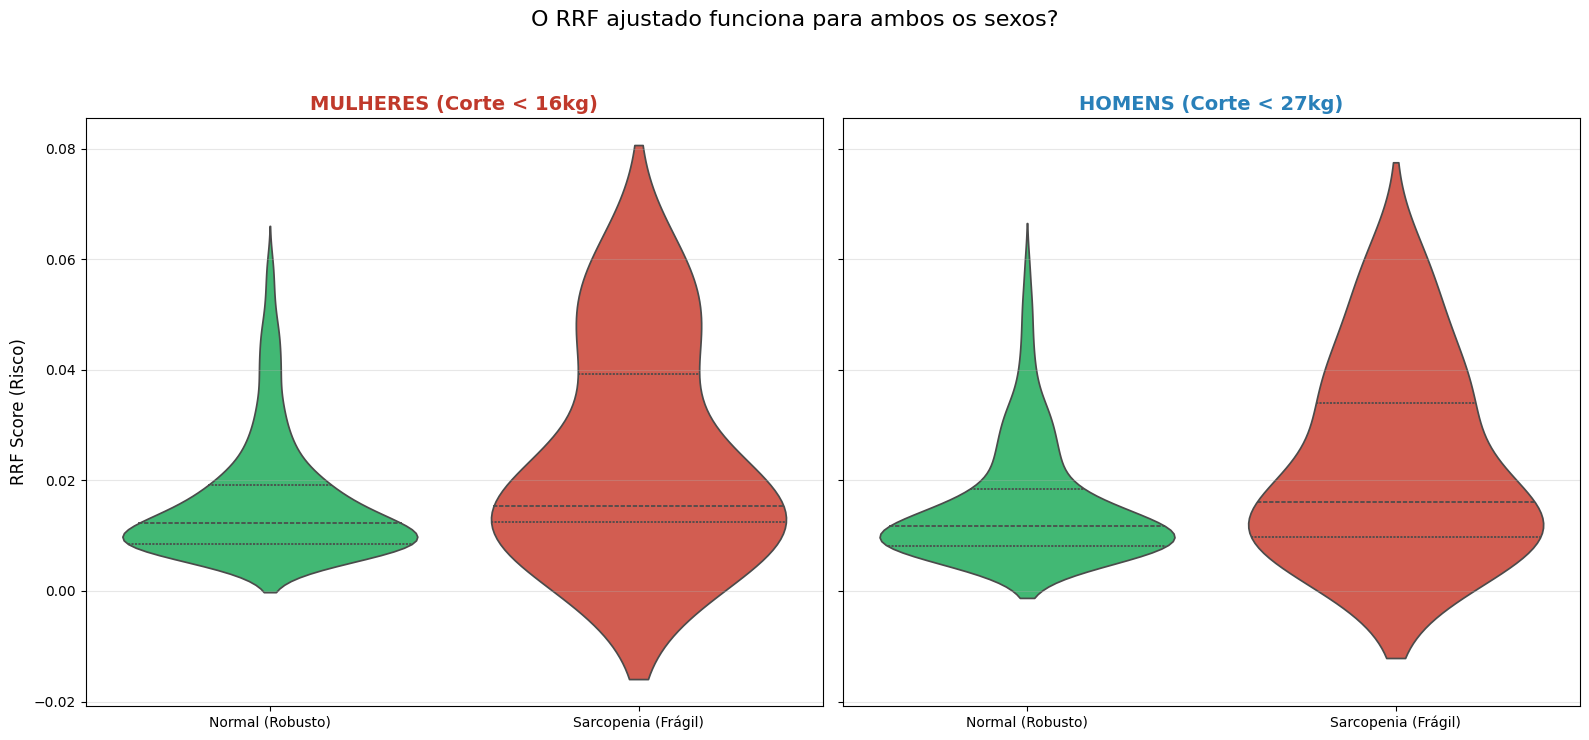

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Aplicar os Cortes Clínicos Oficiais (EWGSOP2)
# Cria uma coluna de "Verdade Clínica" baseada nos Kg reais
def classificar_sarcopenia(row):
    # Assumindo 0 = Mulher, 1 = Homem (ajusta se o teu encoding for diferente)
    if row['Genero'] == 1: # Homem
        return 'Sarcopenia (Frágil)' if row['Real_Kg'] < 27 else 'Normal (Robusto)'
    else: # Mulher
        return 'Sarcopenia (Frágil)' if row['Real_Kg'] < 16 else 'Normal (Robusto)'

df_final['Diagnostico_Clinico'] = df_final.apply(classificar_sarcopenia, axis=1)

# 2. Configurar o Gráfico Duplo
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

# Cores: Verde para Saudável, Vermelho para Doente
cores = {'Normal (Robusto)': '#2ecc71', 'Sarcopenia (Frágil)': '#e74c3c'}

# --- GRÁFICO A: MULHERES ---
sns.violinplot(
    data=df_final[df_final['Genero'] == 0], # Filtra só Mulheres
    x='Diagnostico_Clinico', 
    y='RRF_Score',
    order=['Normal (Robusto)', 'Sarcopenia (Frágil)'], # Ordem fixa
    palette=cores,
    inner='quartile',
    ax=axes[0]
)
axes[0].set_title("MULHERES (Corte < 16kg)", fontsize=14, fontweight='bold', color='#c0392b')
axes[0].set_xlabel("")
axes[0].set_ylabel("RRF Score (Risco)", fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# --- GRÁFICO B: HOMENS ---
sns.violinplot(
    data=df_final[df_final['Genero'] == 1], # Filtra só Homens
    x='Diagnostico_Clinico', 
    y='RRF_Score',
    order=['Normal (Robusto)', 'Sarcopenia (Frágil)'],
    palette=cores,
    inner='quartile',
    ax=axes[1]
)
axes[1].set_title("HOMENS (Corte < 27kg)", fontsize=14, fontweight='bold', color='#2980b9')
axes[1].set_xlabel("")
axes[1].set_ylabel("") # Remove etiqueta redundante
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle("O RRF ajustado funciona para ambos os sexos?", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

## CatBoost Clasifier

--- Computing Target (Sarcopenia) ---

Training CatBoost Classifier...
0:	test: 0.6527911	best: 0.6527911 (0)	total: 9.55ms	remaining: 19.1s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.7984644914
bestIteration = 71

Shrink model to first 72 iterations.

--- Results (threshold tuned for higher Recall(1), F2-optimal) ---
Best threshold: 0.406
ROC-AUC: 0.798
Recall (class 1): 0.792
              precision    recall  f1-score   support

     Healthy      0.973     0.699     0.813       521
  Sarcopenia      0.195     0.792     0.313        48

    accuracy                          0.707       569
   macro avg      0.584     0.745     0.563       569
weighted avg      0.908     0.707     0.771       569



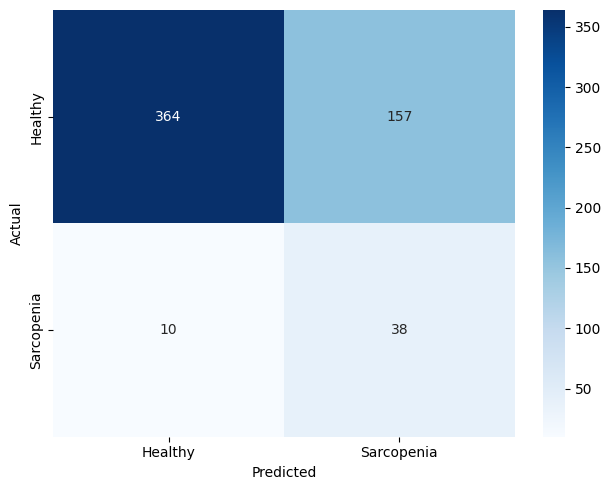

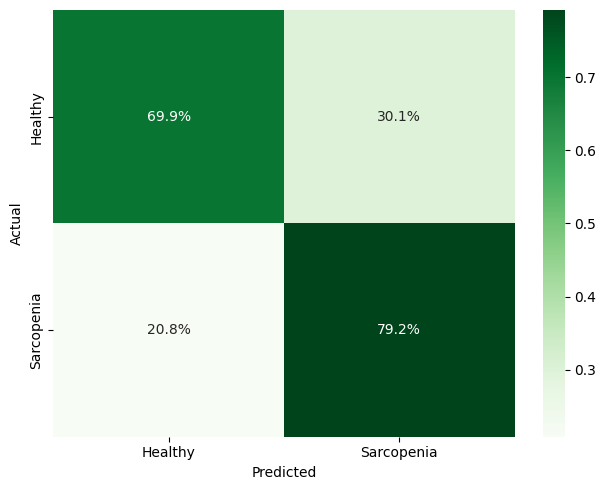

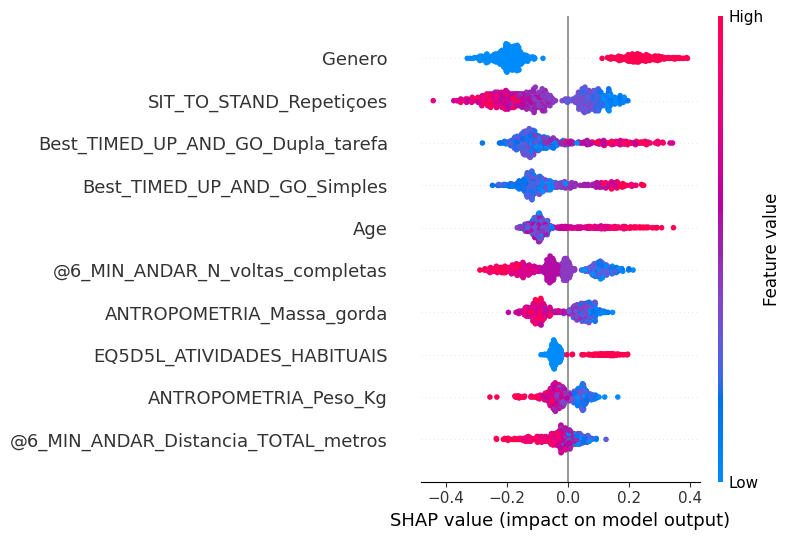

In [ ]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    precision_recall_curve, recall_score
)
from sklearn import __version__ as skver
from packaging.version import Version

from catboost import CatBoostClassifier
import shap

# 1) Define X and y (Sarcopenia from Handgrip + Gender)
print("--- Computing Target (Sarcopenia) ---")

def define_sarcopenia(row):
    g = row.get("Genero", None)
    h = row.get("HANDGRIP_BEST", None)

    if pd.isna(h) or pd.isna(g):
        return 0

    g_str = str(g).upper()
    is_male   = g_str in ["MALE", "M", "1", "1.0", "MASCULINO"]
    is_female = g_str in ["FEMALE", "F", "0", "0.0", "FEMININO"]

    if is_male and h < 27:
        return 1
    if is_female and h < 16:
        return 1
    return 0

y = df_clean.apply(define_sarcopenia, axis=1)

cols_to_drop = full_drop_list + ["Sarcopenia", "Sarcopenia_Class"]
X = df_clean.drop(columns=[c for c in cols_to_drop if c in df_clean.columns], errors="ignore")

if y.sum() < 2:
    raise ValueError("ERROR: Too few Sarcopenia cases. Check your data.")

# 2) Split + Preprocess (Imputation + OHE)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, shuffle=True, stratify=y, random_state=42
)

def make_ohe():
    if Version(skver) >= Version("1.2"):
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    return OneHotEncoder(handle_unknown="ignore", sparse=False)

num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

pre = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), num_cols),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("ohe", make_ohe())
        ]), cat_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

X_train_t = pre.fit_transform(X_train)
X_val_t   = pre.transform(X_val)

try:
    feat_names = pre.get_feature_names_out().tolist()
except Exception:
    feat_names = [f"f{i}" for i in range(X_train_t.shape[1])]

# =======================
# 3) Train CatBoost (balanced via sample weights)
# =======================
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

print("\nTraining CatBoost Classifier...")

cb = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.03,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=200,
    early_stopping_rounds=100,
    allow_writing_files=False,
)

cb.fit(
    X_train_t, y_train,
    sample_weight=sample_weights,
    eval_set=(X_val_t, y_val),
    use_best_model=True
)

# 4) Evaluation + Threshold tuned for higher Recall(1)
y_prob = cb.predict_proba(X_val_t)[:, 1]

# Tune threshold to favor Recall for class 1:
# maximize F-beta with beta>1 (beta=2 emphasizes recall more than precision)
beta = 2.0
prec, rec, thr = precision_recall_curve(y_val, y_prob)
thr = np.append(thr, 1.0)  # align sizes (sklearn returns len(thr)=len(prec)-1)

fbeta = (1 + beta**2) * (prec * rec) / ((beta**2 * prec) + rec + 1e-12)
best_ix = int(np.nanargmax(fbeta))
best_thr = float(thr[best_ix])

y_pred = (y_prob >= best_thr).astype(int)

print(f"\n--- Results (threshold tuned for higher Recall(1), F{beta:.0f}-optimal) ---")
print(f"Best threshold: {best_thr:.3f}")
print(f"ROC-AUC: {roc_auc_score(y_val, y_prob):.3f}")
print(f"Recall (class 1): {recall_score(y_val, y_pred, pos_label=1):.3f}")
print(classification_report(y_val, y_pred, target_names=["Healthy", "Sarcopenia"], digits=3))

# 5) Plots (SEPARATE figures)
labels = ["Healthy", "Sarcopenia"]

# 5A) Confusion Matrix (counts)
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(6.5, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

# 5B) Sensitivity view (row-normalized; each row sums to 1)
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-12)
plt.figure(figsize=(6.5, 5))
sns.heatmap(cm_norm, annot=True, fmt=".1%", cmap="Greens", xticklabels=labels, yticklabels=labels)
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

# 6) SHAP (Top 10 only) + Title
# Optional: subsample for speed
X_shap = X_val_t
if hasattr(X_shap, "shape") and X_shap.shape[0] > 1500:
    rng = np.random.RandomState(42)
    idx = rng.choice(X_shap.shape[0], size=1500, replace=False)
    X_shap = X_shap[idx]

X_shap_df = pd.DataFrame(X_shap, columns=feat_names)

explainer = shap.TreeExplainer(cb)
shap_values = explainer.shap_values(X_shap)

# For binary classification, some versions return [class0, class1]
if isinstance(shap_values, list) and len(shap_values) == 2:
    shap_values_pos = shap_values[1]
else:
    shap_values_pos = shap_values

plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values_pos,
    X_shap_df,
    max_display=10,
    show=False
)
plt.tight_layout()
plt.show()
